In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [4]:
print(f"Total rows: {len(df)}")
print(f"Deck missing %:{round(df['deck'].isnull().sum()/len(df)*100,1)}%")
print(f"Age missing %:{round(df['age'].isnull().sum()/len(df)*100,1)}%")

Total rows: 891
Deck missing %:77.2%
Age missing %:19.9%


In [5]:




#df = df.drop(columns =['deck'])
df['age'] = df['age'].fillna(df['age'].mean())
df = df.dropna(subset = ['embark_town'])
print("Cleaned! remaining missing value:")
print(df.isnull().sum())

Cleaned! remaining missing value:
survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      0
alive            0
alone            0
dtype: int64


In [6]:
print(df['survived'].value_counts())

survived
0    549
1    340
Name: count, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

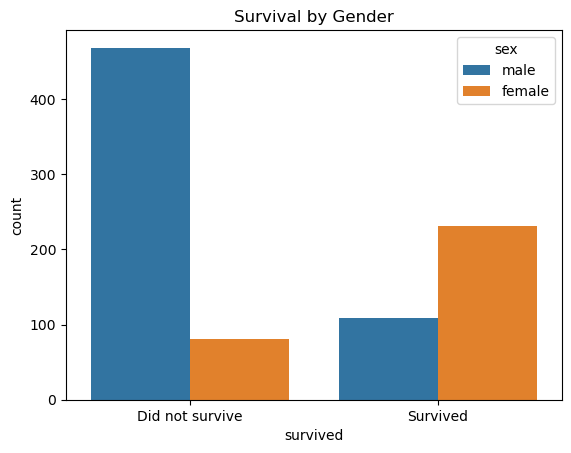

In [7]:
sns.countplot(x='survived',hue='sex',data = df)
plt.title('Survival by Gender')
plt.xticks([0,1],['Did not survive','Survived'])
plt.show

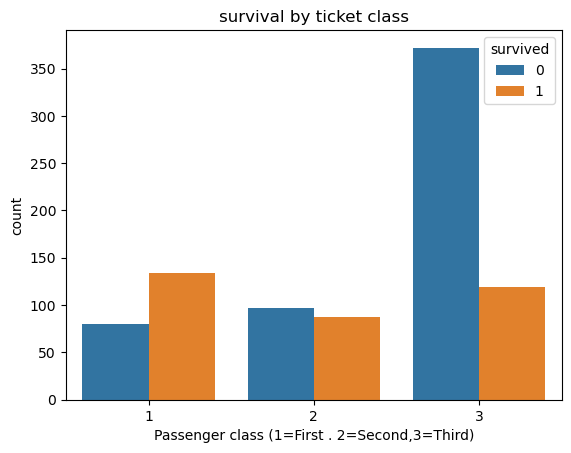

In [8]:
sns.countplot(x='pclass',hue='survived',data = df)
plt.title('survival by ticket class')
plt.xlabel('Passenger class (1=First . 2=Second,3=Third)')
plt.show()

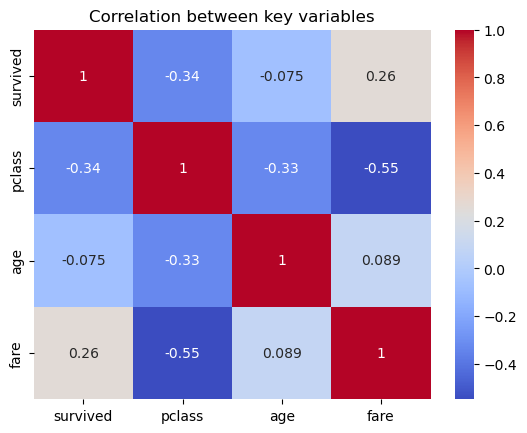

In [9]:
sns.heatmap(df[['survived','pclass','age','fare']].corr(), annot = True , cmap='coolwarm')
plt.title('Correlation between key variables')
plt.show()

In [10]:
df.groupby('survived')['age'].mean()

survived
0    30.4151
1    28.4236
Name: age, dtype: float64

In [11]:
df.groupby(['pclass','sex']).count()

survived  age  sibsp  parch  fare  embarked  class  who  \
pclass sex                                                               
1      female        92   92     92     92    92        92     92   92   
       male         122  122    122    122   122       122    122  122   
2      female        76   76     76     76    76        76     76   76   
       male         108  108    108    108   108       108    108  108   
3      female       144  144    144    144   144       144    144  144   
       male         347  347    347    347   347       347    347  347   

               adult_male  deck  embark_town  alive  alone  
pclass sex                                                  
1      female          92    79           92     92     92  
       male           122    94          122    122    122  
2      female          76    10           76     76     76  
       male           108     6          108    108    108  
3      female         144     6          144    144    144  
       male           347     6          347    347    347

In [12]:
df.groupby('sex')['fare'].mean()

sex
female    44.252124
male      25.523893
Name: fare, dtype: float64

In [13]:
df.groupby('pclass')['survived'].mean()

pclass
1    0.626168
2    0.472826
3    0.242363
Name: survived, dtype: float64

In [14]:
 df.groupby('embark_town')['survived'].mean()


embark_town
Cherbourg      0.553571
Queenstown     0.389610
Southampton    0.336957
Name: survived, dtype: float64

In [15]:
df.groupby('embark_town')['pclass'].mean()

embark_town
Cherbourg      1.886905
Queenstown     2.909091
Southampton    2.350932
Name: pclass, dtype: float64

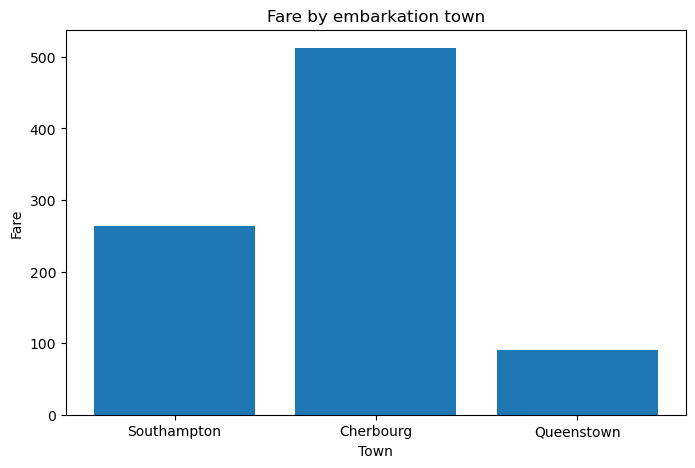

In [16]:
plt.figure(figsize=(8,5))
plt.bar(df['embark_town'],df['fare'])
plt.title('Fare by embarkation town')
plt.xlabel('Town')
plt.ylabel('Fare')
plt.show()


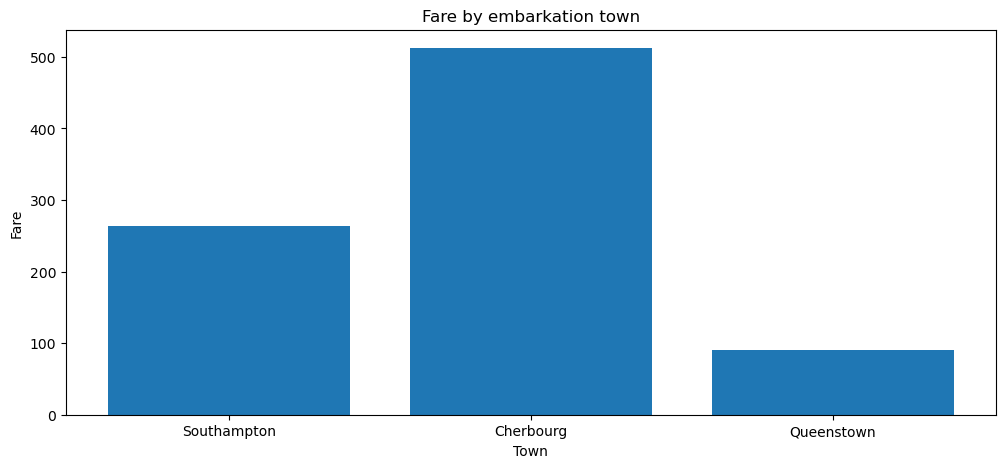

In [17]:
plt.figure(figsize=(12,5))
plt.bar(df['embark_town'], df['fare'])
plt.title('Fare by embarkation town')
plt.xlabel('Town')
plt.ylabel('Fare')
plt.show()

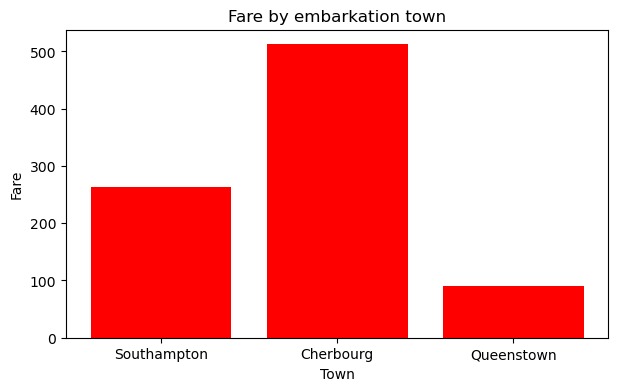

In [18]:
plt.figure(figsize=(7,4))
plt.bar(df['embark_town'], df['fare'],color = 'red')
plt.title('Fare by embarkation town')
plt.xlabel('Town')
plt.ylabel('Fare')
plt.show()

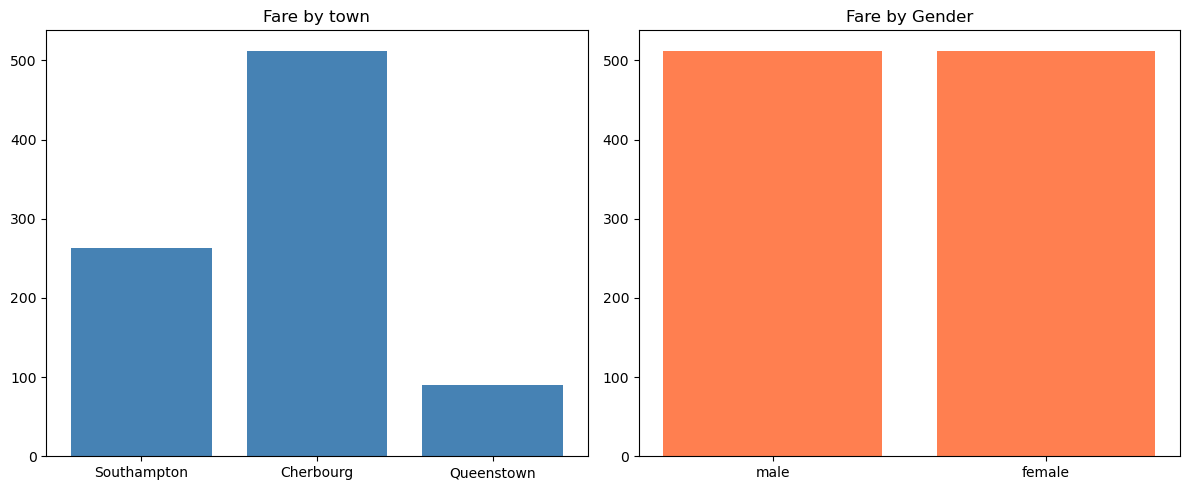

In [19]:
fig, axes = plt.subplots(1,2, figsize=(12,5))
axes[0].bar(df['embark_town'],df['fare'],color='steelblue')
axes[0].set_title('Fare by town')
axes[1].bar(df['sex'],df['fare'],color='coral')
axes[1].set_title('Fare by Gender')
plt.tight_layout()
plt.show()

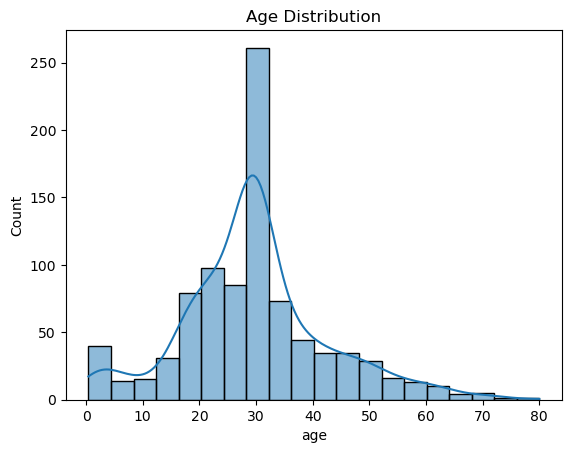

In [20]:
sns.histplot(df['age'],bins = 20,kde=True)
plt.title('Age Distribution')
plt.show()

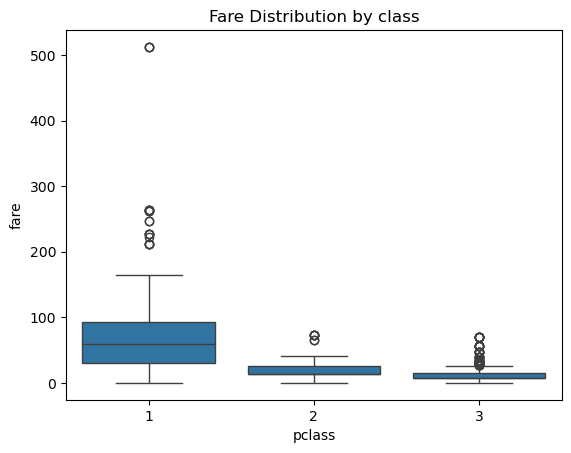

In [21]:
sns.boxplot(x='pclass',y = 'fare',data = df)
plt.title('Fare Distribution by class')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

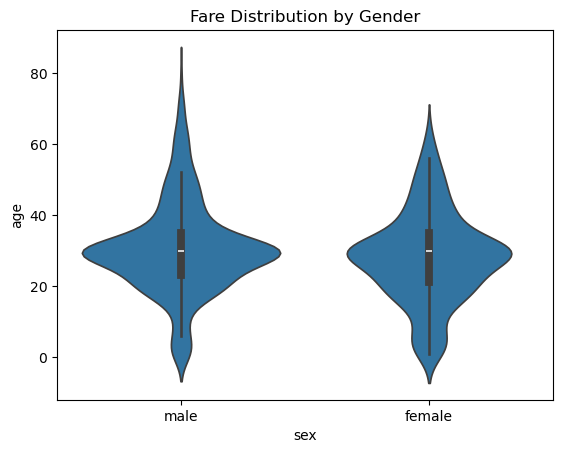

In [22]:
sns.violinplot(x='sex',y='age',data=df)
plt.title('Fare Distribution by Gender')
plt.show

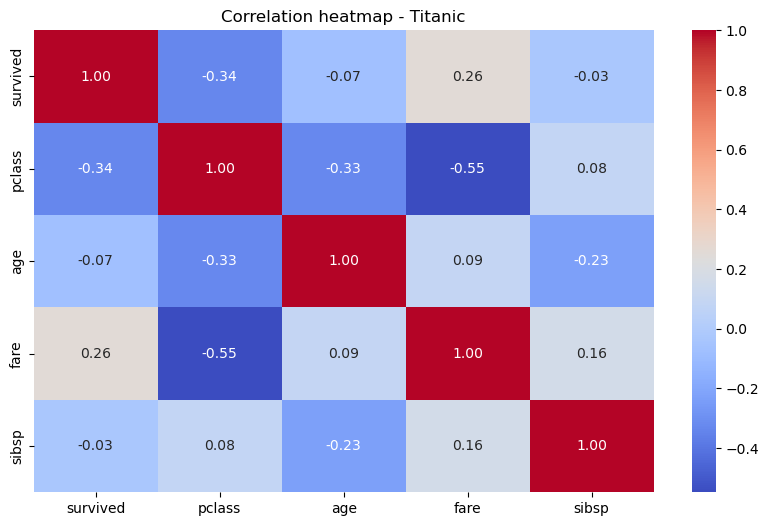

In [23]:
plt.figure(figsize=(10,6)) 
sns.heatmap(df[['survived','pclass','age','fare','sibsp']].corr(),annot = True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation heatmap - Titanic')
plt.show()

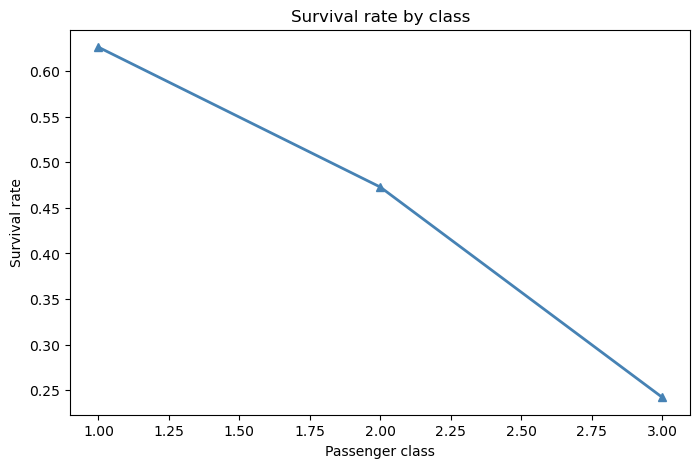

In [26]:
survival_by_class = df.groupby('pclass')['survived'].mean()
plt.figure(figsize=(8,5))
plt.plot(survival_by_class.index, survival_by_class.values,marker = '^' ,color = 'steelblue',linewidth = 2)
plt.title('Survival rate by class')
plt.xlabel('Passenger class')
plt.ylabel('Survival rate')
plt.show()

Text(0.5, 1.0, 'Survival rate by class')

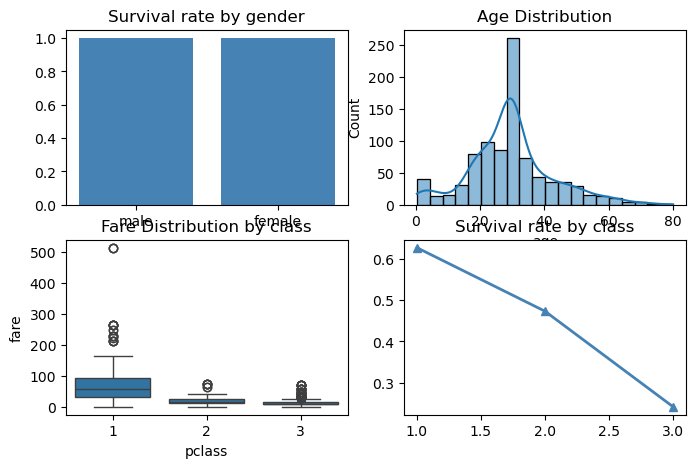

In [40]:
fig, axes = plt.subplots(2,2,figsize=(8,5))
axes[0][0].bar(df['sex'],df['survived'],color ='steelblue')
axes[0][0].set_title('Survival rate by gender')
sns.histplot(df['age'],bins = 20,kde=True, ax = axes[0][1])
axes[0][1].set_title('Age Distribution')
sns.boxplot(x='pclass',y = 'fare',data = df,ax = axes[1][0])
axes[1][0].set_title('Fare Distribution by class')
survival_by_class = df.groupby('pclass')['survived'].mean()
axes[1][1].plot(survival_by_class.index, survival_by_class.values,marker = '^' ,color = 'steelblue',linewidth = 2)
axes[1][1].set_title('Survival rate by class')